In [1]:
import os
import time
import warnings
import h5py
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

import magritte.setup as setup
import magritte.core as magritte
import magritte.plot as plot
import magritte.mesher as mesher
import magritte.tools as tools

warnings.filterwarnings('ignore')
import yt
from yt.funcs import mylog
mylog.setLevel(40)

from astropy import constants
from astropy.io import fits
from scipy.spatial import Delaunay

# -----------------------------
# Vectorized Physics Functions -- CONSTANT AMMONIA ABUNDANCE HAS BEEN ASSUMED FOR SIMPLICITY
# -----------------------------
def get_properties_vectorized(positions, rho_cloud, r_out, XNH3, T_cloud, vturb):
    """Calculates all cell properties using fast, vectorized Numpy operations."""
    m_H2 = 2.01588 * constants.u.si.value
    background_density = 1e2 * 1e6 * m_H2

    # Radii of all points
    r = np.linalg.norm(positions, axis=1)
    
    # Densities -- Constant Density Sphere with background outside
    gas_density = np.where(r > r_out, background_density, rho_cloud)

    nH2 = gas_density / m_H2
    nNH3 = XNH3 * nH2

    # Temperature and Turbulence (constant arrays)
    tmp = np.full(len(positions), T_cloud, dtype=np.float64)
    trb = np.full(len(positions), (vturb / constants.c.si.value) ** 2, dtype=np.float64)

    # Velocity (Assuming v_radial = 0 based on original code logic)
    # If v_radial becomes non-zero, replace 0.0 with your v_radial value
    v_radial = 0.0 
    velocity = np.zeros_like(positions)
    if v_radial != 0.0:
        safe_r = np.where(r == 0, 1.0, r) # avoid division by zero at origin
        velocity[:, 0] = v_radial * (positions[:, 0] / safe_r)
        velocity[:, 1] = v_radial * (positions[:, 1] / safe_r)
        velocity[:, 2] = v_radial * (positions[:, 2] / safe_r)
    velocity = velocity / 3e8

    return nH2, nNH3, tmp, trb, velocity

In [9]:
def run_model(wdir="/home/yasho379/magritte_rebuilt/production/tgs/" , odir = "/home/yasho379/magritte_rebuilt/production/tgs/"):
    XNH3=1e-7 
    numberdensity=1e8
    vturb=100
    T_cloud=35 
    max_NLTE=20 
    radius_sphere=1e16
    
    model_file = os.path.join(wdir, f'model_files/NLTE_analytic_sphere_nh3_{XNH3}_{numberdensity:.2e}_{radius_sphere:.2e}_{vturb}_{T_cloud}.hdf5')
    lamda_file = os.path.join(wdir, 'p-nh3@loreau.dat.txt')

    m_H2 = 2.01588 * constants.u.si.value
    rho_cloud = numberdensity * 1.0E6 * m_H2   
    r_out = radius_sphere / 100  
    resolution = 5

    xs = np.linspace(-r_out , +r_out , resolution, endpoint=True)
    ys = np.linspace(-r_out , +r_out , resolution, endpoint=True)
    zs = np.linspace(-r_out , +r_out , resolution, endpoint=True)
    Xs, Ys, Zs = np.meshgrid(xs, ys, zs)

    position = np.column_stack((Xs.ravel(), Ys.ravel(), Zs.ravel()))

    # Rough density map for remesher
    r_dist = np.linalg.norm(position, axis=1)
    background_density = 1e2 * 1e6 * m_H2
    rhos_ravel = np.where(r_dist > r_out, background_density, rho_cloud)

    positions_reduced, nb_boundary = mesher.remesh_point_cloud(
        position, rhos_ravel, max_depth=5, threshold=2e-1, hullorder=3
    )

    origin = np.array([0.0, 0.0, 0.0]).T
    positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_inner_boundary(
        positions_reduced, nb_boundary, 0.01 * r_out, healpy_order=3, origin=origin
    )
    positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_outer_boundary(
        positions_reduced, nb_boundary, r_out, healpy_order=3, origin=origin
    )
    npoints = len(positions_reduced)

    delaunay = Delaunay(positions_reduced)
    indptr, indices = delaunay.vertex_neighbor_vertices
    neighbors = [indices[indptr[k]:indptr[k + 1]] for k in range(npoints)]
    nbs = [n for sublist in neighbors for n in sublist]
    n_nbs = [len(sublist) for sublist in neighbors]

    # Get vectorized physical properties
    nH2, nNH3, tmp, trb, velocity = get_properties_vectorized(
        positions_reduced, rho_cloud, r_out, XNH3, T_cloud, vturb
    )
    zeros = np.zeros(npoints)

    ds = yt.load_unstructured_mesh(
    connectivity = delaunay.simplices.astype(np.int64),
    coordinates  = delaunay.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'n'): nH2[delaunay.simplices].astype(np.float64)}
)
    
    sl = yt.SlicePlot (ds, 'z', ('connect1', 'n'))
    sl.set_cmap       (('connect1', 'n'), 'magma')
    sl.zoom           (0.9)
    model = magritte.Model() 
    model.parameters.set_model_name(model_file)
    model.parameters.set_dimension(3)
    model.parameters.set_npoints(npoints)
    model.parameters.set_nrays(12 * 1 * 1)
    model.parameters.set_nspecs(3)
    model.parameters.set_nlspecs(1)
    model.parameters.set_nquads(20)
    model.parameters.sum_opacity_emissivity_over_all_lines = True
    model.parameters.pop_prec = 1.0e-6

    model.geometry.points.position.set(positions_reduced)
    model.geometry.points.velocity.set(velocity)
    model.geometry.points.neighbors.set(nbs)
    model.geometry.points.n_neighbors.set(n_nbs)

    model.chemistry.species.abundance = np.column_stack((nNH3, nH2, zeros))
    model.chemistry.species.symbol = ['p-NH3', 'H2', 'e-']

    model.thermodynamics.temperature.gas.set(tmp)
    model.thermodynamics.turbulence.vturb2.set(trb)

    model.parameters.set_nboundary(nb_boundary)
    model.geometry.boundary.boundary2point.set(np.arange(nb_boundary))

    setup.set_uniform_rays(model)
    setup.set_boundary_condition_CMB(model)
    setup.set_linedata_from_LAMDA_file(model, lamda_file)
    setup.set_quadrature(model)

    max_write_attempts = 3
    write_success = False
        
    for attempt in range(1, max_write_attempts + 1):
        try:
            model.write(model_file)
            write_success = True
            break
        except Exception as e:
            if attempt < max_write_attempts:
                time.sleep(2)
            else:
                print(f"CRITICAL ERROR: Failed to write model file: {e}")
                raise

    if write_success and os.path.exists(model_file):
        try:
            with h5py.File(model_file, 'r') as f:
                pass # Check valid read
        except Exception as e:
            raise RuntimeError(f"CRITICAL ERROR: File is corrupt! {e}")
    else:
        raise FileNotFoundError("File was not found!")
    return sl
    
sl = run_model()
sl.show()


new interior points:  98
number boundary points:  386


TypeError: get_properties_vectorized() missing 1 required positional argument: 'vturb'

In [10]:
import os
import time
import warnings
import h5py
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

import magritte.setup as setup
import magritte.core as magritte
import magritte.plot as plot
import magritte.mesher as mesher
import magritte.tools as tools

warnings.filterwarnings('ignore')
import yt
from yt.funcs import mylog
mylog.setLevel(40)

from astropy import constants
from astropy.io import fits
from scipy.spatial import Delaunay

# -----------------------------
# Vectorized Physics Functions
# -----------------------------
def get_properties_vectorized(positions, rho_center, r_core, decay_index, XNH3, T_cloud, vturb):
    """Calculates cell properties using a core plateau + power-law envelope."""
    m_H2 = 2.01588 * constants.u.si.value
    background_density = 1e2 * 1e6 * m_H2

    # Radii of all points
    r = np.linalg.norm(positions, axis=1)
    
    # 1. Inside the core: r_eff = r_core
    # 2. Outside the core: r_eff = r
    r_eff = np.maximum(r, r_core)
    
    # Calculate density: constant inside core, decaying outside
    gas_density = rho_center * (r_eff / r_core)**(-decay_index)

    # Floor the density at the ambient background
    gas_density = np.maximum(gas_density, background_density)

    nH2 = gas_density / m_H2
    nNH3 = XNH3 * nH2

    # Temperature and Turbulence (constant arrays)
    tmp = np.full(len(positions), T_cloud, dtype=np.float64)
    trb = np.full(len(positions), (vturb / constants.c.si.value) ** 2, dtype=np.float64)

    # Velocity (Static)
    velocity = np.zeros_like(positions)

    return nH2, nNH3, tmp, trb, velocity

new interior points:  4999
number boundary points:  386



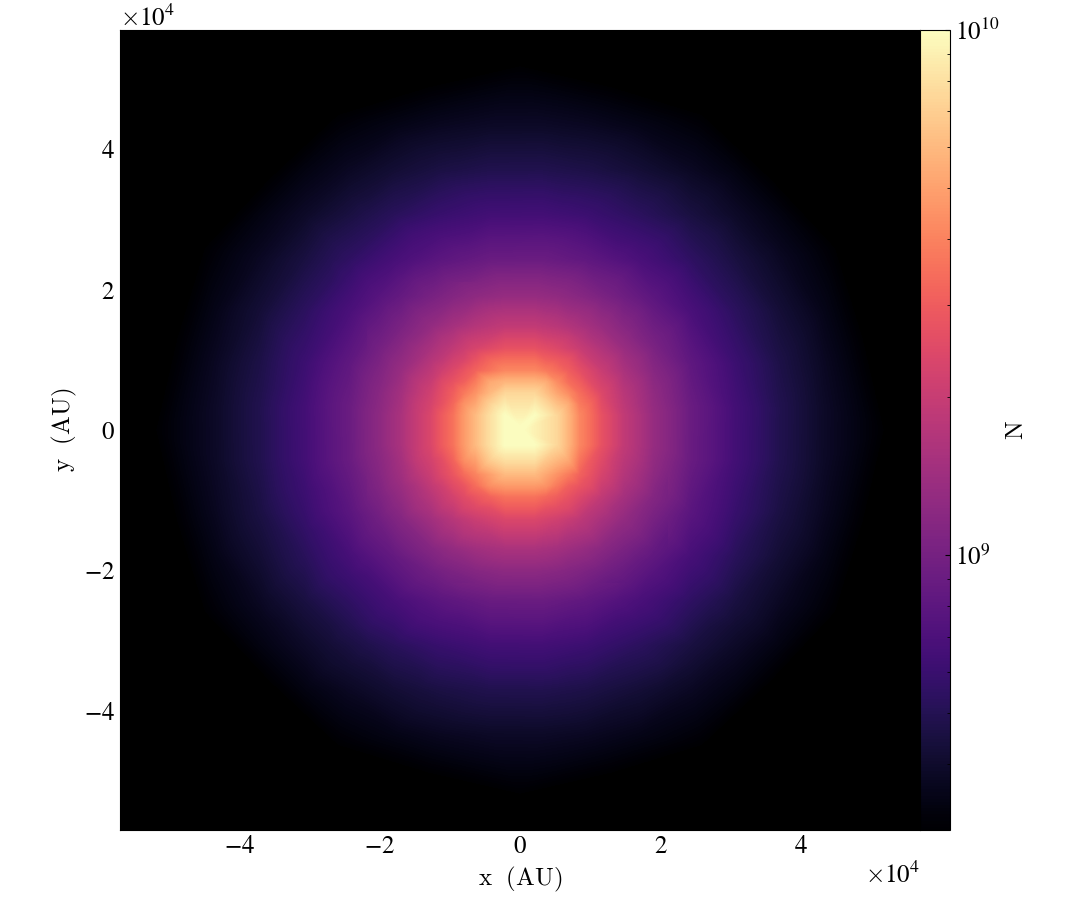

In [26]:
def run_model(wdir, odir, XNH3=1e-7, numberdensity=1e5, vturb=100, T_cloud=35, max_NLTE=20, decay_index=1.5, r_core_au=5000):
    
    # Updated all file naming to use decay_index instead of radius
    model_file = os.path.join(wdir, f'model_files/NLTE_analytic_sphere_nh3_{XNH3}_{numberdensity:.2e}_{decay_index:.2f}_{vturb}_{T_cloud}.hdf5')
    lamda_file = os.path.join(wdir, 'p-nh3@loreau.dat.txt')

    m_H2 = 2.01588 * constants.u.si.value
    rho_center = numberdensity * 1.0E6 * m_H2   
    background_density = 1e2 * 1e6 * m_H2
    r_core = r_core_au * constants.au.si.value

    # Calculate outer boundary (r_out) where density = 3 * background
    target_density = 3.0 * background_density
    
    if rho_center > target_density and decay_index > 0:
        r_out = r_core * (rho_center / target_density)**(1.0 / decay_index)
    else:
        # Fallback to prevent meshing errors if central density is very low
        r_out = r_core * 1.5 
        
    resolution = 50

    xs = np.linspace(-r_out , +r_out , resolution, endpoint=True)
    ys = np.linspace(-r_out , +r_out , resolution, endpoint=True)
    zs = np.linspace(-r_out , +r_out , resolution, endpoint=True)
    Xs, Ys, Zs = np.meshgrid(xs, ys, zs)

    position = np.column_stack((Xs.ravel(), Ys.ravel(), Zs.ravel()))

    # Rough density map for remesher
    r_dist = np.linalg.norm(position, axis=1)
    r_eff_rough = np.maximum(r_dist, r_core)
    rhos_ravel = rho_center * (r_eff_rough / r_core)**(-decay_index)
    rhos_ravel = np.maximum(rhos_ravel, background_density)

    positions_reduced, nb_boundary = mesher.remesh_point_cloud(
        position, rhos_ravel, max_depth=5, threshold=2e-1, hullorder=3
    )

    origin = np.array([0.0, 0.0, 0.0]).T
    positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_inner_boundary(
        positions_reduced, nb_boundary, 0.01 * r_out, healpy_order=3, origin=origin
    )
    positions_reduced, nb_boundary = mesher.point_cloud_add_spherical_outer_boundary(
        positions_reduced, nb_boundary, r_out, healpy_order=3, origin=origin
    )
    npoints = len(positions_reduced)

    delaunay = Delaunay(positions_reduced)
    indptr, indices = delaunay.vertex_neighbor_vertices
    neighbors = [indices[indptr[k]:indptr[k + 1]] for k in range(npoints)]
    nbs = [n for sublist in neighbors for n in sublist]
    n_nbs = [len(sublist) for sublist in neighbors]

    # Get vectorized physical properties
    nH2, nNH3, tmp, trb, velocity = get_properties_vectorized(
        positions_reduced, rho_center, r_core, decay_index, XNH3, T_cloud, vturb
    )
    zeros = np.zeros(npoints)

    ds = yt.load_unstructured_mesh(
    connectivity = delaunay.simplices.astype(np.int64),
    coordinates  = delaunay.points.astype(np.float64) * 100.0, # yt expects cm not m 
    node_data    = {('connect1', 'n'): nH2[delaunay.simplices].astype(np.float64)}
)
    
    sl = yt.SlicePlot (ds, 'z', ('connect1', 'n'))
    sl.set_cmap       (('connect1', 'n'), 'magma')
    return sl

sl = run_model(wdir="./", odir="./", XNH3=1e-8, numberdensity=1e4, vturb=300, T_cloud=35, max_NLTE=100, decay_index=1.5, r_core_au=5000)
sl.show()